<div style="font-size:20px"> In 2024, incidents have seen a 20% increase from 2022. This leads to the findings of the root causes. We would like to understand the followings: <ul> <li>are longer trips more risker than shorter trips?</li> <li> are certain routes more risker than others</li> <li> is the company compensated enough for the more risker trips</li></ul> </div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_safety_incidents

Path to dataset files: C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1


In [3]:
# Set the default figure size
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(color_codes = True)
pd.set_option('display.width', 1200)
pd.set_option('display.max_columns', None)

In [4]:
safety_df = load_safety_incidents()
print(safety_df.isnull().sum())

incident_id            0
trip_id                0
truck_id               1
driver_id              1
incident_date          0
incident_type          0
location_city          0
location_state         0
at_fault_flag          0
injury_flag            0
vehicle_damage_cost    0
cargo_damage_cost      0
claim_amount           0
preventable_flag       0
description            0
dtype: int64


In [5]:
safety_df['incident_date']=pd.to_datetime(safety_df['incident_date'])
safety_df['year']=pd.to_datetime(safety_df['incident_date']).dt.year
safety_df['month_year']=pd.to_datetime(safety_df['incident_date']).dt.to_period('M')

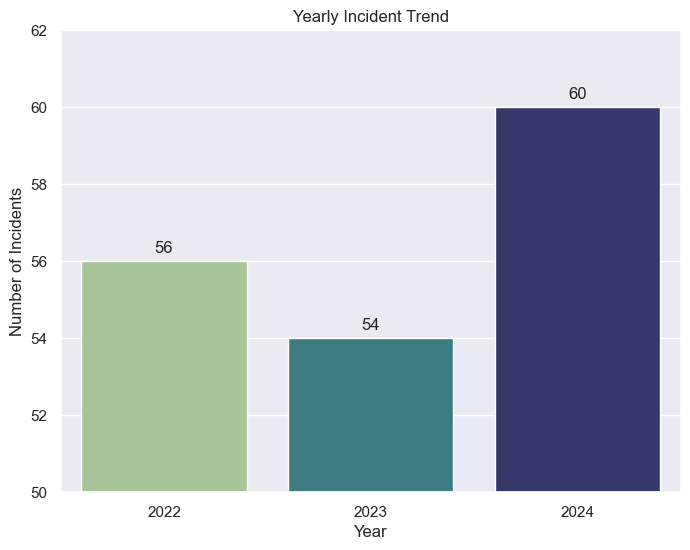

In [6]:
yearly_incidents = (
    safety_df.groupby('year')['incident_id']
    .count()
    .reset_index()
)

plt.figure(figsize=(8, 6))

# Update: Assign x to hue and set legend=False to satisfy the new Seaborn requirements
ax = sns.barplot(
    data=yearly_incidents, 
    x='year', 
    y='incident_id', 
    hue='year', 
    palette='crest', 
    legend=False
)

# THE TRICK: Zoom in on the Y-axis to make the jump from 54 to 60 look more dramatic
# Since your min is 54 and max is 60, starting at 50 makes the change very clear
plt.ylim(50, 62) 

# Add data labels on top of the bars so the exact numbers are visible
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Yearly Incident Trend')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.show()